# Research03 Validate Data
 
 Research03은 Research02에서 생성한 anomaly windows가 같은 RandomForestClassifier의 최종 성능을 개선하는지 확인한다.
 
 > Research02 masking generation은 data-driven adaptive temporal-block + feature-group masking으로 변경되었다. 이 노트북은 Research02를 먼저 재실행한 뒤 실행해야 한다.


## 1. 실험 아이디어

이전 방식은 생성 데이터를 넣은 뒤 validation threshold를 고르는 과정이 섞여 있어서, 성능 향상이 모델 학습 때문인지 threshold 조정 때문인지 구분하기 어려웠다.

이번 실험은 다음처럼 구성한다.

```text
Baseline 학습 데이터:
normal train + real anomaly seed

Augmented 학습 데이터:
normal train + real anomaly seed + generated anomaly N개

N:
50, 100, 200, 500, 1000

공통 평가:
real validation으로 threshold 선택
final test로 최종 성능 평가
```

따라서 augmented 방법이 baseline보다 좋아지면 **생성 데이터가 모델 학습 자체에 기여했다**고 해석할 수 있다. 생성 데이터 개수를 바꿔 보면서 어느 정도의 augmentation이 가장 효과적인지도 함께 확인한다.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SPLIT_DIR = ROOT / "data" / "augmentation_split"
GENERATED_DIR = ROOT / "data" / "research02" / "generated"
RESEARCH02_RESULT_DIR = ROOT / "data" / "research02" / "results"
RESEARCH02_FIGURE_DIR = ROOT / "data" / "research02" / "figures"
RESEARCH03_RESULT_DIR = ROOT / "data" / "research03" / "results"
RESEARCH03_FIGURE_DIR = ROOT / "data" / "research03" / "figures"
SCRIPT_PATH = ROOT / "tools" / "research03_model_augmented_validation.py"
RESEARCH02_SUMMARY_PATH = RESEARCH02_RESULT_DIR / "research02_generation_summary.json"

with open(RESEARCH02_SUMMARY_PATH, "r", encoding="utf-8") as f:
    research02_summary = json.load(f)

required_keys = {"masking_strategy", "masking_diffusion_denoiser", "temporal_block_ratio", "feature_group_ratio", "adaptive_masking"}
missing = required_keys - set(research02_summary)
if missing:
    raise RuntimeError(f"Research02 generated data is stale. Rerun Research02 first. Missing keys: {sorted(missing)}")

print("ROOT:", ROOT)
print("script exists:", SCRIPT_PATH.exists())
display(research02_summary)


ROOT: c:\Users\gram\Desktop\Research
script exists: True


{'generation_fix': 'Generation follows the paper-style comparison: unmasked GT-GAN and Diffusion sample full windows from noise, while masking-based methods use real anomaly windows with structured masked-value restoration.',
 'masking_strategy': 'Masking-based methods use data-driven adaptive temporal block masking and feature-group masking instead of element-wise random masking. Time regions are sampled with higher probability when normal-anomaly distributional differences are larger, and feature groups are formed from anomaly-feature correlation and normal-anomaly feature differences. The observed seed values are preserved, and only masked time/feature regions are restored by the generator.',
 'adaptive_masking': {'strategy': 'data_driven_adaptive_temporal_feature_group_masking',
  'normal_sample_size': 5000,
  'temporal_block_ratio': 0.25,
  'feature_group_ratio': 0.4,
  'block_len': 8,
  'group_len': 2,
  'top_time_starts': [22, 21, 20, 2, 3],
  'top_feature_groups': [['RealPower'

## 2. 사용 데이터

모델 학습과 평가를 위해 만들어 둔 window 데이터를 사용한다.

- `normal_train_windows.npz`: 정상 학습 데이터
- `anomaly_train_seed_windows.npz`: 실제 anomaly seed 데이터
- `validation_windows.npz`: threshold 선택용 실제 validation 데이터
- `final_test_windows.npz`: 최종 평가 데이터
- Research02 생성 데이터 4종
  - GT-GAN
  - Masking GT-GAN, data-driven adaptive temporal-block + feature-group masking 기반
  - Diffusion
  - Masking Diffusion, data-driven adaptive temporal-block + feature-group masking 기반


In [2]:
def load_npz(path):
    data = np.load(path, allow_pickle=True)
    x = data["X"]
    y = data["y"] if "y" in data.files else None
    return x, y

rows = []
for name, path in {
    "normal_train": SPLIT_DIR / "normal_train_windows.npz",
    "real_anomaly_seed": SPLIT_DIR / "anomaly_train_seed_windows.npz",
    "validation": SPLIT_DIR / "validation_windows.npz",
    "final_test": SPLIT_DIR / "final_test_windows.npz",
    "GT-GAN generated": GENERATED_DIR / "gtgan_series_windows.npz",
    "Masking GT-GAN generated": GENERATED_DIR / "gtgan_masked_windows.npz",
    "Diffusion generated": GENERATED_DIR / "diffusion_series_windows.npz",
    "Masking Diffusion generated": GENERATED_DIR / "diffusion_masked_windows.npz",
}.items():
    x, y = load_npz(path)
    row = {
        "data": name,
        "shape": str(x.shape),
        "normal": int((y == 0).sum()) if y is not None else 0,
        "anomaly": int((y == 1).sum()) if y is not None else len(x),
    }
    rows.append(row)

data_summary = pd.DataFrame(rows)
display(data_summary)


,data,shape,normal,anomaly
0,normal_train,"(135730, 30, 5)",135730,0
1,real_anomaly_seed,"(247, 30, 5)",0,247
2,validation,"(1447, 30, 5)",1283,164
3,final_test,"(3081, 30, 5)",2785,296
4,GT-GAN generated,"(1000, 30, 5)",0,1000
5,Masking GT-GAN generated,"(1000, 30, 5)",0,1000
6,Diffusion generated,"(1000, 30, 5)",0,1000
7,Masking Diffusion generated,"(1000, 30, 5)",0,1000


## 3. t-SNE 결과와 생성 데이터 품질

Research02의 t-SNE에서는 generated anomaly가 real anomaly 주변에 얼마나 머무르는지 확인한다.

이 시각화는 다음처럼 해석한다.

- real anomaly와 generated anomaly가 많이 겹치면 생성 데이터가 실제 이상 패턴을 어느 정도 보존했을 가능성이 있다.
- 하지만 t-SNE는 시각적 참고 자료일 뿐이므로 이것만으로 최종 결론을 내리지는 않는다.
- 이 노트북에서는 downstream RandomForest 성능으로 다시 검증한다.


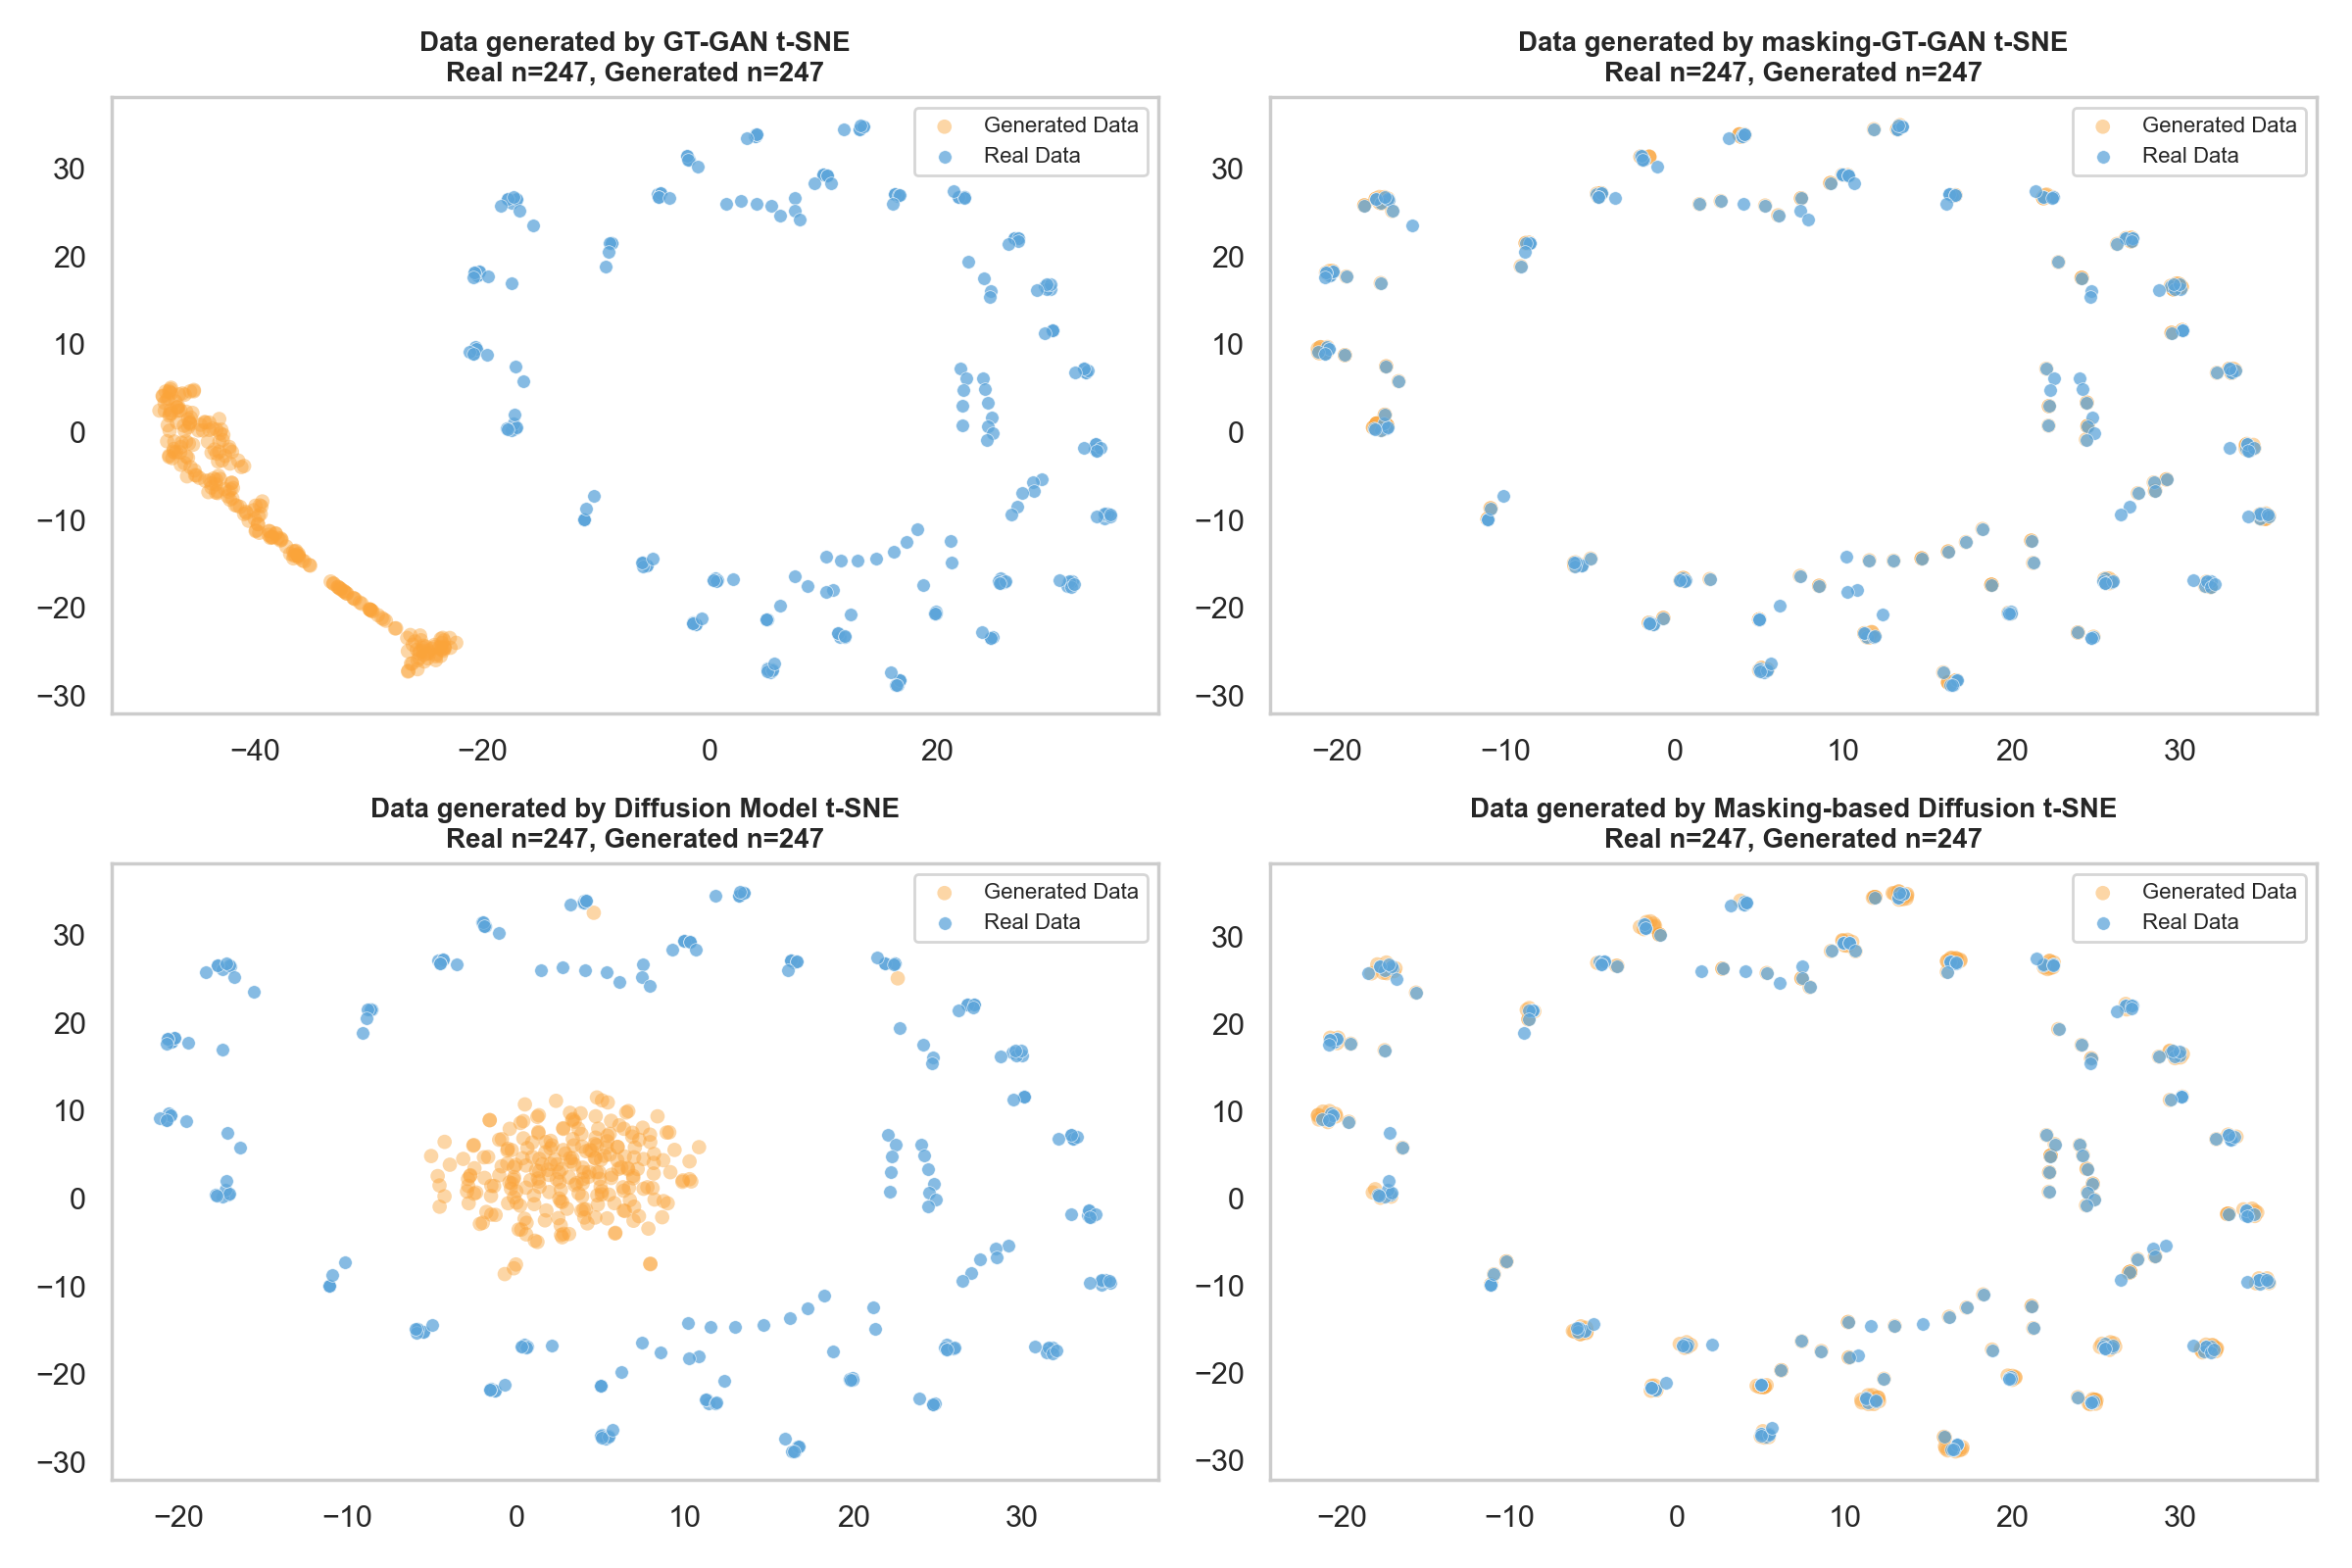

,method,n_real,n_generated,mean_abs_diff,std_abs_diff,corr_abs_diff,real_min,real_max,generated_min,generated_max
0,Masking GT-GAN,247,1000,0.003390,0.000555,0.001185,-2.657036,1.308221,-2.662160,1.314599
1,Masking Diffusion,247,1000,0.011099,0.011542,0.011258,-2.657036,1.308221,-2.984906,1.559348
2,Diffusion,247,1000,0.109781,0.297728,0.355872,-2.657036,1.308221,-2.984906,1.559348
3,GT-GAN,247,1000,0.787542,0.335290,0.450976,-2.657036,1.308221,-2.764305,1.066077


In [3]:
tsne_path = RESEARCH02_FIGURE_DIR / "tsne_2x2_real_vs_generated_full.png"
if tsne_path.exists():
    display(Image(filename=str(tsne_path)))
else:
    print("t-SNE figure not found:", tsne_path)

quality_path = RESEARCH02_RESULT_DIR / "generated_quality_metrics.csv"
if quality_path.exists():
    quality_df = pd.read_csv(quality_path)
    display(quality_df)
else:
    print("quality metrics not found:", quality_path)


## 4. 모델 자체 개선 실험 설계

이번 실험에서는 `RandomForestClassifier`를 사용한다. 이유는 다음과 같다.

- 정상 데이터와 anomaly 데이터를 함께 학습하는 supervised model이다.
- 생성 anomaly를 학습 데이터에 직접 추가할 수 있다.
- Research01 baseline과 Research03 augmented 실험을 같은 모델로 비교할 수 있다.

비교 방법은 다음과 같다.

| 방법 | 학습 데이터 |
|---|---|
| Real anomaly only | normal + real anomaly seed |
| GT-GAN | normal + real anomaly seed + GT-GAN 생성 anomaly N개 |
| Masking GT-GAN | normal + real anomaly seed + adaptive structured masking GT-GAN 생성 anomaly N개 |
| Diffusion | normal + real anomaly seed + Diffusion 생성 anomaly N개 |
| Masking Diffusion | normal + real anomaly seed + adaptive structured masking Diffusion 생성 anomaly N개 |

생성 anomaly 개수 `N`은 다음처럼 바꿔 가며 비교한다.

```text
N = 50, 100, 200, 500, 1000
```

중요한 통제 조건은 다음과 같다.

- 모든 방법은 같은 normal train sample을 사용한다.
- 모든 방법은 같은 real anomaly seed 247개를 사용한다.
- 생성 데이터만 50, 100, 200, 500, 1000개로 바꾼다.
- threshold는 생성 데이터가 아니라 실제 validation 데이터에서만 선택한다.
- 최종 성능은 final test에서만 비교한다.


In [4]:
result = subprocess.run(
    [sys.executable, str(SCRIPT_PATH)],
    cwd=ROOT,
    text=True,
    capture_output=True,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Research03 model-level validation failed")


               method                   model  ...  true_normal  true_anomaly
20  Masking Diffusion  RandomForestClassifier  ...         2785           296
10     Masking GT-GAN  RandomForestClassifier  ...         2785           296
19  Masking Diffusion  RandomForestClassifier  ...         2785           296
9      Masking GT-GAN  RandomForestClassifier  ...         2785           296
15          Diffusion  RandomForestClassifier  ...         2785           296
8      Masking GT-GAN  RandomForestClassifier  ...         2785           296
18  Masking Diffusion  RandomForestClassifier  ...         2785           296
4              GT-GAN  RandomForestClassifier  ...         2785           296
7      Masking GT-GAN  RandomForestClassifier  ...         2785           296
17  Masking Diffusion  RandomForestClassifier  ...         2785           296
1              GT-GAN  RandomForestClassifier  ...         2785           296
14          Diffusion  RandomForestClassifier  ...         2785 

## 5. 최종 성능 비교

아래 표는 final test 기준 성능이다.

해석할 때는 특히 다음 지표를 본다.

- `generated_anomaly_used`: 학습에 추가한 생성 anomaly 개수
- `recall`: 실제 anomaly를 얼마나 놓치지 않는가
- `f1`: precision과 recall의 균형
- `auprc`: anomaly class가 적은 상황에서 ranking 품질이 좋은가

생성 데이터를 추가한 방법이 `Real anomaly only`보다 높으면 생성 데이터가 모델 학습에 유익했다는 뜻이다. 같은 방법 안에서 `generated_anomaly_used`가 늘어날 때 성능이 어떻게 변하는지도 확인한다.


In [5]:
performance_path = RESEARCH03_RESULT_DIR / "supervised_model_augmented_performance.csv"
performance_df = pd.read_csv(performance_path)

cols = [
    "method",
    "generated_anomaly_used",
    "threshold_selected_on_real_validation",
    "precision",
    "recall",
    "f1",
    "auroc",
    "auprc",
    "pred_anomaly",
]

display(performance_df[cols].round(4))


,method,generated_anomaly_used,threshold_selected_on_real_validation,precision,recall,f1,auroc,auprc,pred_anomaly
0,Masking Diffusion,1000,0.87,0.9617,0.7635,0.8512,0.9901,0.9376,235
1,Masking GT-GAN,1000,0.90,0.9464,0.7162,0.8154,0.9723,0.8718,224
2,Masking Diffusion,500,0.89,0.9716,0.6926,0.8087,0.9855,0.9142,211
3,Masking GT-GAN,500,0.90,0.9030,0.7230,0.8030,0.9666,0.8613,237
4,Diffusion,1000,0.85,0.8378,0.7331,0.7820,0.9803,0.8809,259
5,Masking GT-GAN,200,0.91,0.9124,0.6689,0.7719,0.9617,0.8344,217
6,Masking Diffusion,200,0.91,0.9838,0.6149,0.7568,0.9737,0.8618,185
7,GT-GAN,500,0.89,0.9728,0.6047,0.7458,0.9729,0.8531,184
8,Masking GT-GAN,100,0.91,0.8750,0.6385,0.7383,0.9598,0.8178,216
9,Masking Diffusion,100,0.90,0.8636,0.6419,0.7364,0.9685,0.8355,220


## 6. Baseline 대비 개선량

아래 표는 `Real anomaly only` 대비 각 생성 데이터 추가 방법이 얼마나 좋아졌는지 보여준다.

- `delta_recall > 0`: 실제 anomaly를 더 많이 잡음
- `delta_f1 > 0`: 전체 이상 탐지 균형이 좋아짐
- `delta_auprc > 0`: anomaly score ranking이 좋아짐


In [6]:
baseline = performance_df.loc[performance_df["method"] == "Real anomaly only"].iloc[0]
comparison_df = performance_df.copy()

for metric in ["precision", "recall", "f1", "auroc", "auprc"]:
    comparison_df[f"delta_{metric}"] = comparison_df[metric] - baseline[metric]

delta_cols = [
    "method",
    "delta_precision",
    "delta_recall",
    "delta_f1",
    "delta_auroc",
    "delta_auprc",
]

display(comparison_df[delta_cols].round(4))


,method,delta_precision,delta_recall,delta_f1,delta_auroc,delta_auprc
0,Masking Diffusion,0.1066,0.1453,0.1336,0.0312,0.1377
1,Masking GT-GAN,0.0913,0.0980,0.0977,0.0134,0.0719
2,Masking Diffusion,0.1164,0.0743,0.0910,0.0266,0.1143
3,Masking GT-GAN,0.0478,0.1047,0.0854,0.0077,0.0614
4,Diffusion,-0.0173,0.1149,0.0643,0.0214,0.0810
5,Masking GT-GAN,0.0573,0.0507,0.0543,0.0028,0.0344
6,Masking Diffusion,0.1286,-0.0034,0.0391,0.0148,0.0619
7,GT-GAN,0.1177,-0.0135,0.0282,0.0140,0.0532
8,Masking GT-GAN,0.0199,0.0203,0.0206,0.0009,0.0178
9,Masking Diffusion,0.0085,0.0236,0.0188,0.0096,0.0356


## 7. 그림으로 확인

아래 그림은 생성 데이터를 학습에 추가했을 때 모델 성능이 어떻게 달라지는지 보여준다.

- `supervised_model_augmented_performance.png`: 생성 데이터 개수별 주요 성능 변화
- `supervised_model_augmented_f1_recall_auprc.png`: F1과 AUPRC 중심 변화
- `best_per_generated_count.png`: 각 생성 개수에서 가장 좋은 방법의 성능
- `best_supervised_confusion_matrix.png`: 전체 실험 중 가장 좋은 방법의 confusion matrix


supervised_model_augmented_performance.png


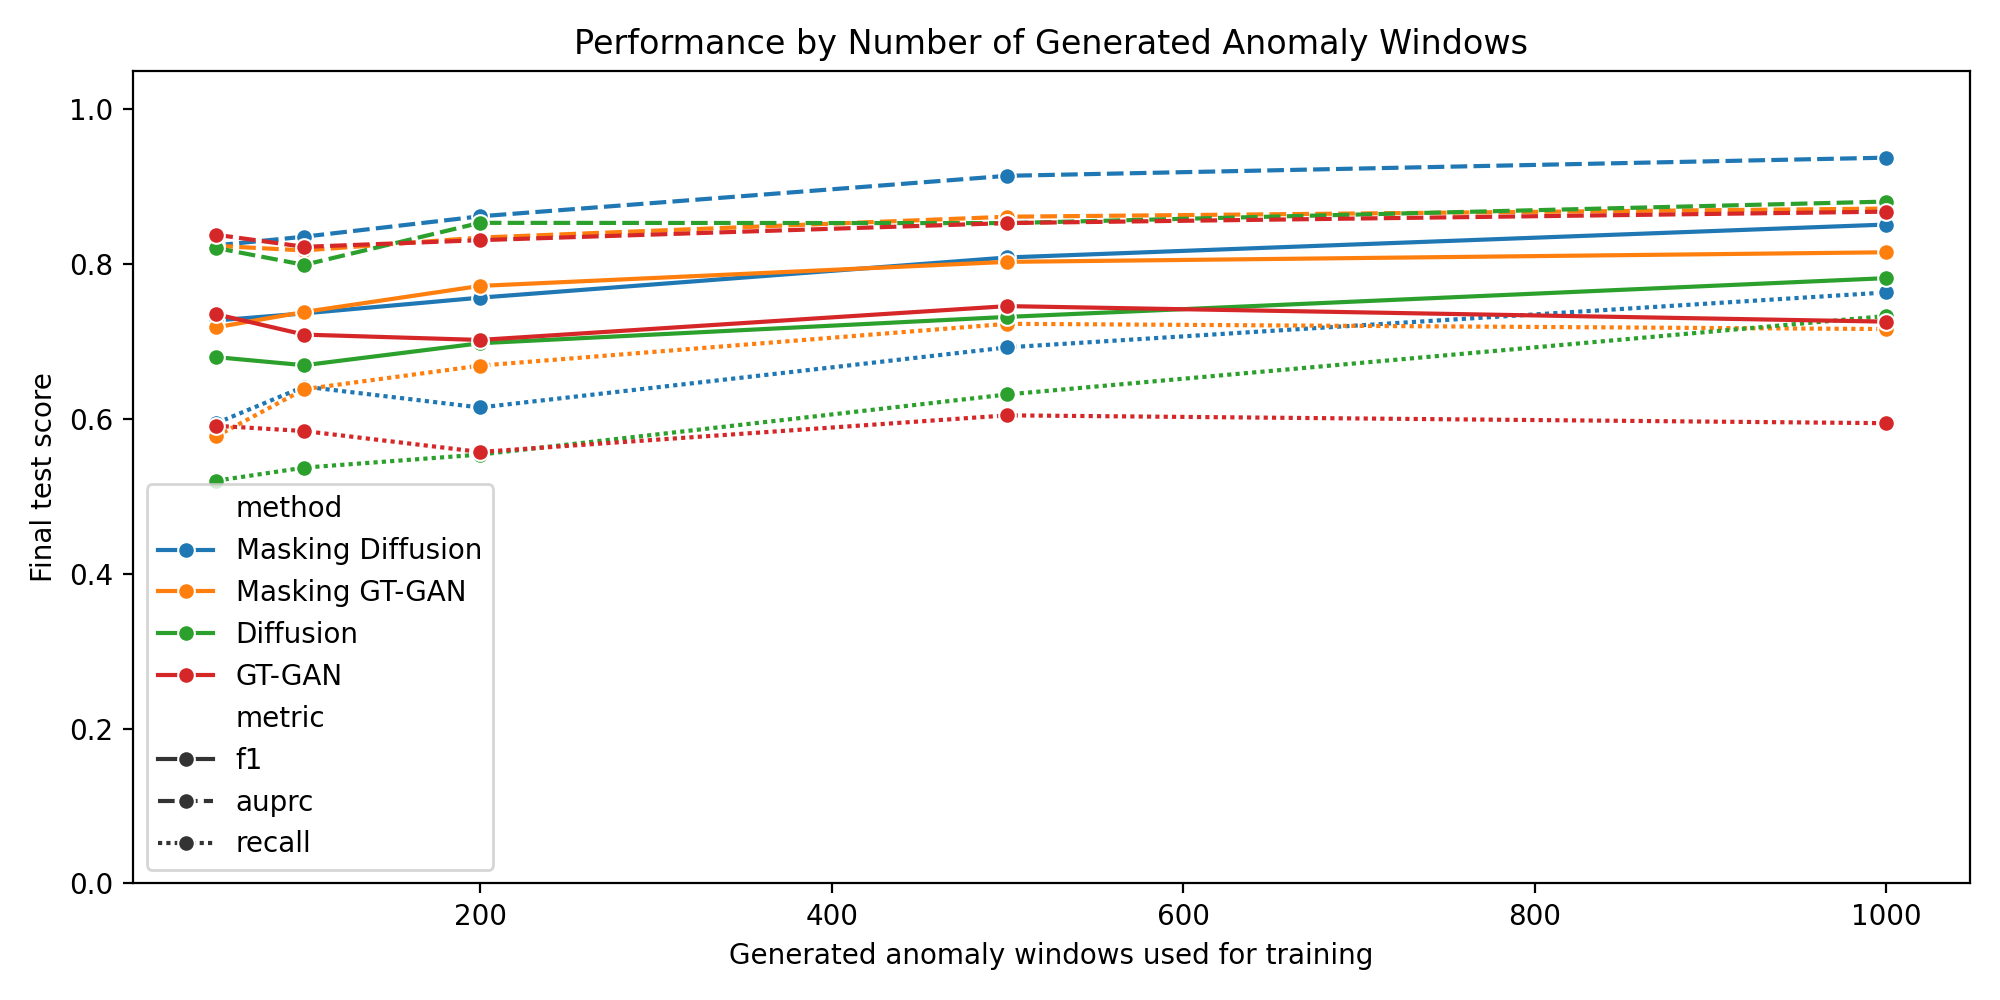

supervised_model_augmented_f1_recall_auprc.png


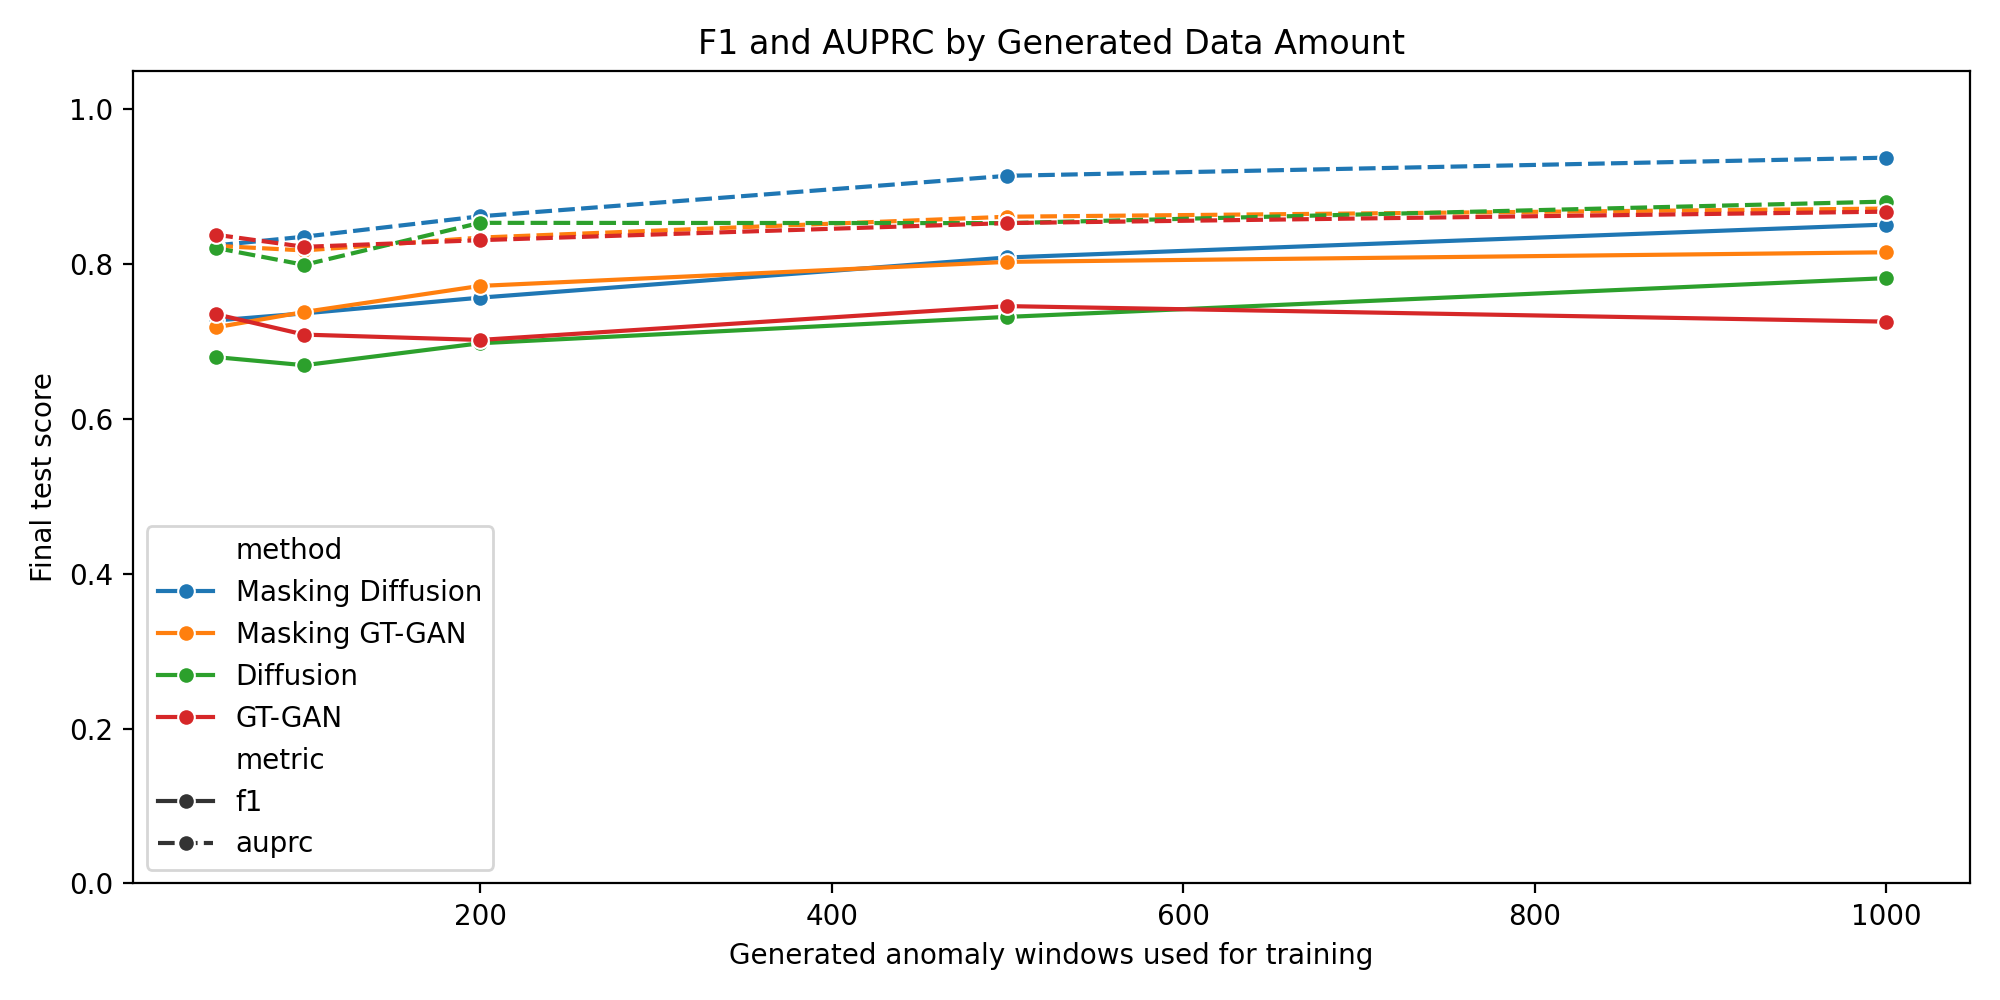

best_per_generated_count.png


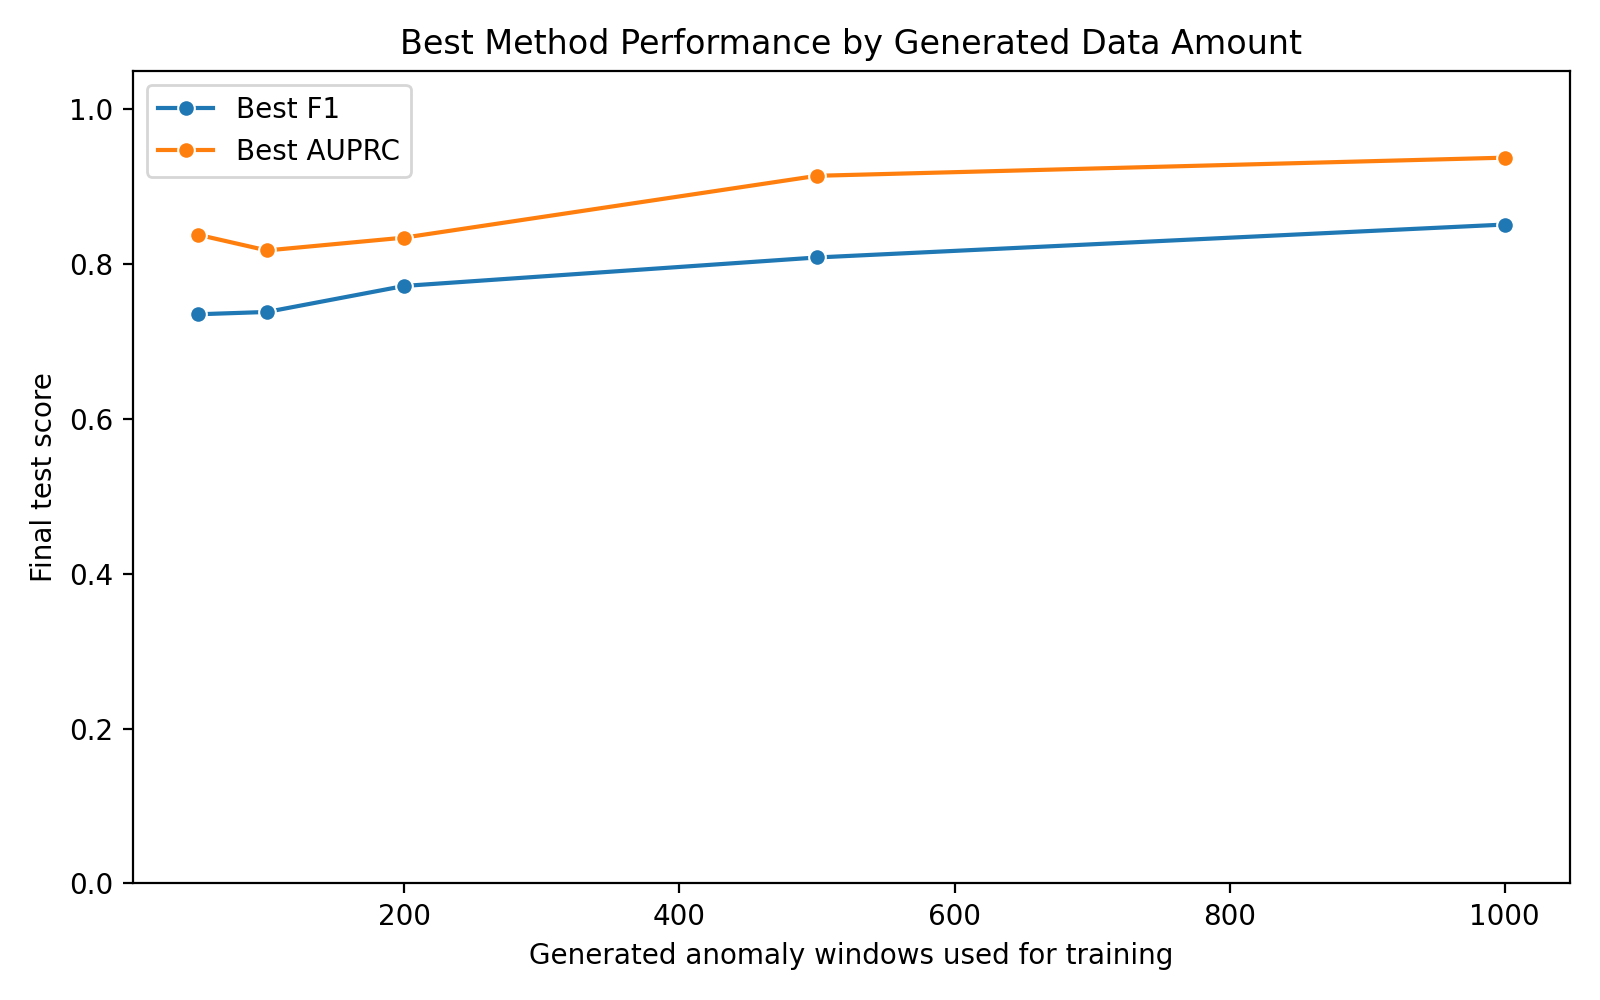

best_supervised_confusion_matrix.png


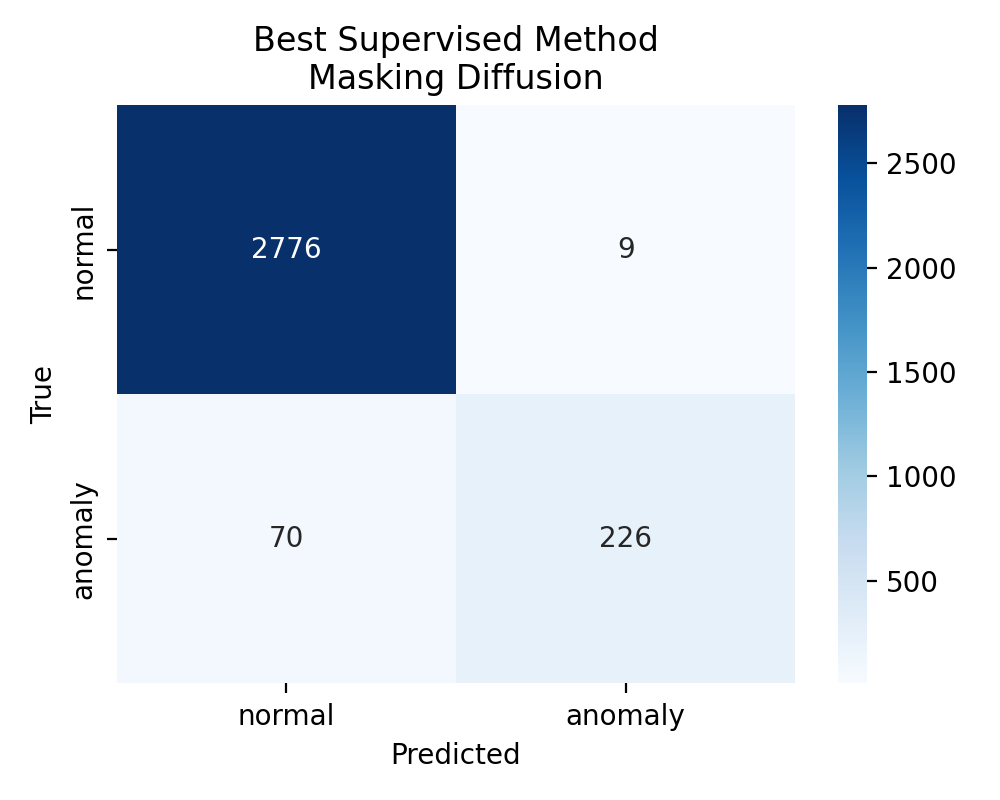

In [7]:
for figure_name in [
    "supervised_model_augmented_performance.png",
    "supervised_model_augmented_f1_recall_auprc.png",
    "best_per_generated_count.png",
    "best_supervised_confusion_matrix.png",
]:
    figure_path = RESEARCH03_FIGURE_DIR / figure_name
    print(figure_name)
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print("not found:", figure_path)


## 8. 결론 작성 방향
 
 아래 결론은 재실행된 `research03_model_improvement_summary.json`과 `supervised_model_augmented_performance.csv`를 기준으로 작성한다. 이전 Research02 결과에서 나온 고정 수치는 사용하지 않는다.
 
 확인할 핵심은 다음과 같다.
 
 - data-driven adaptive structured masking으로 생성된 `Masking GT-GAN`, `Masking Diffusion`이 plain GT-GAN/Diffusion 대비 개선되는가
 - 생성 데이터 수 `50, 100, 200, 500, 1000`에 따라 F1, Recall, AUPRC가 어떻게 변하는가
 - t-SNE/quality metric의 분포 유사성과 downstream 성능이 같은 방향으로 움직이는가
 
 보고서에는 최종 재실행 결과의 best method, generated count, F1, Recall, AUPRC를 표에서 읽어 반영한다.


In [8]:
summary_path = RESEARCH03_RESULT_DIR / "research03_model_improvement_summary.json"
with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

print("Best method:", summary["best_method"])
print("Performance ranking by F1:")
for i, method in enumerate(summary["performance_ranking_by_f1"], start=1):
    print(f"{i}. {method}")


Best method: Masking Diffusion
Performance ranking by F1:
1. Masking Diffusion
2. Masking GT-GAN
3. Masking Diffusion
4. Masking GT-GAN
5. Diffusion
6. Masking GT-GAN
7. Masking Diffusion
8. GT-GAN
9. Masking GT-GAN
10. Masking Diffusion
11. GT-GAN
12. Diffusion
13. Masking Diffusion
14. GT-GAN
15. Masking GT-GAN
16. Real anomaly only
17. GT-GAN
18. GT-GAN
19. Diffusion
20. Diffusion
21. Diffusion
